# Assignment #02 — Telco Monthly Charge Prediction
**EECE 6544 · Summer 2026**

Given which add-on services a customer subscribes to, predict their expected monthly charge using multivariable linear regression.

In [1]:
import sys, subprocess
def pipq(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "-q", "install", *pkgs])

pipq("scikit-learn", "pandas", "numpy", "matplotlib", "seaborn")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", 60)
np.random.seed(0)
print("pandas", pd.__version__)

pandas 2.2.2


## 1. Load and Inspect the Data

In [2]:
from google.colab import files
uploaded = files.upload()   # upload telco.csv when prompted

Saving telco.csv to telco.csv


In [3]:
df = pd.read_csv("telco.csv")
df.columns = df.columns.str.strip()
print("shape:", df.shape)
df.head(3)

shape: (7043, 24)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,target,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,29.85,29.85,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,0,0,0,0,56.95,1889.5,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,0,1,1,0,0,0,0,1,53.85,108.15,1,0,0,0,0,0,0,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   MultipleLines                          7043 non-null   int64  
 7   OnlineSecurity                         7043 non-null   int64  
 8   OnlineBackup                           7043 non-null   int64  
 9   DeviceProtection                       7043 non-null   int64  
 10  TechSupport                            7043 non-null   int64  
 11  Stre

In [5]:
df.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,target,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.504756,0.162147,0.483033,0.299588,32.371149,0.903166,0.421837,0.286668,0.344881,0.343888,0.290217,0.384353,0.387903,0.592219,64.761692,0.265370,0.439585,0.216669,0.209144,0.240664,0.216101,0.335794,0.228880
std,0.500013,0.368612,0.499748,0.458110,24.559481,0.295752,0.493888,0.452237,0.475363,0.475038,0.453895,0.486477,0.487307,0.491457,30.090047,0.441561,0.496372,0.412004,0.406726,0.427517,0.411613,0.472301,0.420141
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.350000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.850000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
# confirm target column and check for missing values
print("Target column — MonthlyCharges stored as 'target'")
print("Missing values per column:")
print(df.isnull().sum())

Target column — MonthlyCharges stored as 'target'
Missing values per column:
gender                                   0
SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
PhoneService                             0
MultipleLines                            0
OnlineSecurity                           0
OnlineBackup                             0
DeviceProtection                         0
TechSupport                              0
StreamingTV                              0
StreamingMovies                          0
PaperlessBilling                         0
target                                   0
TotalCharges                             0
Churn                                    0
InternetService_Fiber optic              0
InternetService_No                       0
Contract_One year                        0
Contract_Two year                        0
PaymentMethod_Credit

In [7]:
# verify the 10 service columns are clean 0/1 indicators
feature_cols = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'InternetService_Fiber optic', 'InternetService_No'
]

print("Unique values in each service column:")
for col in feature_cols:
    print(f"  {col}: {sorted(df[col].unique())}")

Unique values in each service column:
  PhoneService: [np.int64(0), np.int64(1)]
  MultipleLines: [np.int64(0), np.int64(1)]
  OnlineSecurity: [np.int64(0), np.int64(1)]
  OnlineBackup: [np.int64(0), np.int64(1)]
  DeviceProtection: [np.int64(0), np.int64(1)]
  TechSupport: [np.int64(0), np.int64(1)]
  StreamingTV: [np.int64(0), np.int64(1)]
  StreamingMovies: [np.int64(0), np.int64(1)]
  InternetService_Fiber optic: [np.int64(0), np.int64(1)]
  InternetService_No: [np.int64(0), np.int64(1)]


All 10 service columns are clean 0/1 indicators with no missing values, so no additional cleaning needed.

## 2. Define Variables

In [8]:
# target = MonthlyCharges (stored as 'target')
# predictors = the 10 service indicator columns

X = df[feature_cols]
y = df['target']

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head(3)

X shape: (7043, 10)
y shape: (7043,)


,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,InternetService_Fiber optic,InternetService_No
0,0,0,0,1,0,0,0,0,0,0
1,1,0,1,0,1,0,0,0,0,0
2,1,0,1,1,0,0,0,0,0,0


In [9]:
# quick look at min/max/mean to confirm all features are 0/1
print("missing:", X.isnull().any().any())
X.describe().T[['min', 'max', 'mean']]

missing: False


,min,max,mean
PhoneService,0.0,1.0,0.903166
MultipleLines,0.0,1.0,0.421837
OnlineSecurity,0.0,1.0,0.286668
OnlineBackup,0.0,1.0,0.344881
DeviceProtection,0.0,1.0,0.343888
TechSupport,0.0,1.0,0.290217
StreamingTV,0.0,1.0,0.384353
StreamingMovies,0.0,1.0,0.387903
InternetService_Fiber optic,0.0,1.0,0.439585
InternetService_No,0.0,1.0,0.216669


## 3. Split the Data (80/20)

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)

Train size: (5634, 10)
Test size:  (1409, 10)


## 4. Fit the Multivariable Linear Regression

In [11]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## 5. Report the Parameters

In [12]:
# intercept = base plan cost before any add-ons
print("Base plan (intercept): $%.2f / mo" % model.intercept_)

Base plan (intercept): $24.97 / mo


In [13]:
# coefficients = dollar contribution of each service
price_list = pd.DataFrame({
    'service': feature_cols,
    'monthly_contribution ($)': model.coef_
}).sort_values('monthly_contribution ($)', ascending=False).reset_index(drop=True)

price_list

,service,monthly_contribution ($)
0,InternetService_Fiber optic,24.951892
1,PhoneService,20.036039
2,StreamingTV,9.980786
3,StreamingMovies,9.946628
4,OnlineSecurity,5.045880
5,TechSupport,5.028676
6,MultipleLines,5.012293
7,DeviceProtection,5.011923
8,OnlineBackup,4.979713
9,InternetService_No,-25.047916


In [14]:
print("Most expensive add-on: ", price_list.iloc[0]['service'],
      f"(+${price_list.iloc[0]['monthly_contribution ($)']:.2f}/mo)")
print("Cheapest add-on:       ", price_list.iloc[-1]['service'],
      f"(${price_list.iloc[-1]['monthly_contribution ($)']:.2f}/mo)")

Most expensive add-on:  InternetService_Fiber optic (+$24.95/mo)
Cheapest add-on:        InternetService_No ($-25.05/mo)


## 6. Evaluate on the Test Set

In [16]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_pred = model.predict(X_test)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("R2  :", round(r2,   3))
print("MAE : $", round(mae,  2))
print("RMSE: $", round(rmse, 2))

R2  : 0.999
MAE : $ 0.79
RMSE: $ 1.05


In [17]:
# actual vs predicted on a sample of the held-out customers
results = X_test.copy()
results['actual']    = y_test.values
results['predicted'] = y_pred.round(2)
results['error']     = (results['actual'] - results['predicted']).round(2)
results.head(10)

,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,InternetService_Fiber optic,InternetService_No,actual,predicted,error
185,0,0,0,0,0,0,0,0,0,0,24.80,24.97,-0.17
2715,1,1,0,0,0,0,0,0,0,1,25.25,24.97,0.28
3825,1,0,0,0,0,0,0,0,0,1,19.35,19.96,-0.61
1807,1,0,0,0,1,0,0,0,1,0,76.35,74.97,1.38
132,1,0,0,0,0,1,0,0,0,0,50.55,50.03,0.52
1263,1,1,0,1,0,0,0,1,1,0,89.60,89.90,-0.30
3732,1,1,1,0,1,1,1,0,0,0,77.15,75.08,2.07
1672,1,1,1,1,1,1,0,0,0,0,72.10,70.08,2.02
811,1,1,1,0,0,1,1,1,1,0,104.00,104.97,-0.97
2526,1,0,0,0,0,0,0,0,0,1,19.40,19.96,-0.56


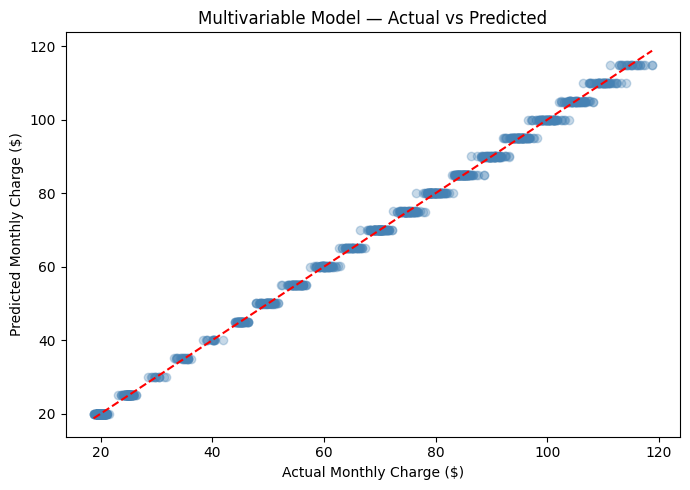

In [18]:
# scatter plot: actual vs predicted
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
plt.xlabel('Actual Monthly Charge ($)')
plt.ylabel('Predicted Monthly Charge ($)')
plt.title('Multivariable Model — Actual vs Predicted')
plt.tight_layout()
plt.savefig('chart_actual_vs_predicted.png', dpi=150)
plt.show()

## 7. Compare to Baseline (Single-Variable Model)

In [20]:
# baseline: single feature = count of add-ons
addon_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
              'TechSupport', 'StreamingTV', 'StreamingMovies']

X_count = df[[]].assign(num_addons=df[addon_cols].sum(axis=1))

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_count, y, test_size=0.2, random_state=42
)

baseline = LinearRegression()
baseline.fit(Xc_train, yc_train)
yc_pred = baseline.predict(Xc_test)

In [21]:
compare = pd.DataFrame({
    'model':    ['Single-variable (count of add-ons)', 'Multivariable (each service)'],
    'R2':       [r2_score(yc_test, yc_pred),            r2_score(y_test, y_pred)],
    'MAE ($)':  [mean_absolute_error(yc_test, yc_pred), mean_absolute_error(y_test, y_pred)],
    'RMSE ($)': [mean_squared_error(yc_test, yc_pred)**0.5, mean_squared_error(y_test, y_pred)**0.5]
}).round(3)

compare

,model,R2,MAE ($),RMSE ($)
0,Single-variable (count of add-ons),0.599,16.970,19.062
1,Multivariable (each service),0.999,0.789,1.050


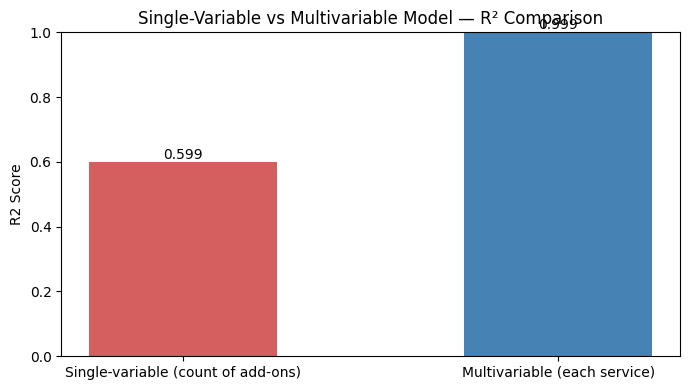

In [23]:
# bar chart comparing R2 of both models
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(compare['model'], compare['R2'], color=['#d45f5f', 'steelblue'], width=0.5)
ax.set_ylim(0, 1)
ax.set_ylabel('R2 Score')
ax.set_title('Single-Variable vs Multivariable Model — R² Comparison')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('chart_model_comparison.png', dpi=150)
plt.show()

## 8. Interpret the Results

In [ ]:
# visualising the coefficients as a horizontal bar chart
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['steelblue' if v >= 0 else '#d45f5f' for v in price_list['monthly_contribution ($)']]
ax.barh(price_list['service'], price_list['monthly_contribution ($)'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Monthly Contribution ($)')
ax.set_title('Estimated Monthly Price of Each Add-On Service')
plt.tight_layout()
plt.savefig('chart_coefficients.png', dpi=150)
plt.show()

In [26]:
print("--- Business interpretation ---")
print(f"Base plan (no add-ons): ${model.intercept_:.2f}/mo\n")

for _, row in price_list.iterrows():
    direction = "adds" if row['monthly_contribution ($)'] >= 0 else "reduces bill by"
    print(f"  {row['service']:35s} {direction} ${abs(row['monthly_contribution ($)']):.2f}/mo")

--- Business interpretation ---
Base plan (no add-ons): $24.97/mo

  InternetService_Fiber optic         adds $24.95/mo
  PhoneService                        adds $20.04/mo
  StreamingTV                         adds $9.98/mo
  StreamingMovies                     adds $9.95/mo
  OnlineSecurity                      adds $5.05/mo
  TechSupport                         adds $5.03/mo
  MultipleLines                       adds $5.01/mo
  DeviceProtection                    adds $5.01/mo
  OnlineBackup                        adds $4.98/mo
  InternetService_No                  reduces bill by $25.05/mo


Each coefficient is the model's best estimate of how much that service costs per month. Fiber optic internet is the most expensive add-on by a large margin, which makes sense, it's a premium tier upgrade. `InternetService_No` has a negative coefficient because customers with no internet skip all the internet-dependent services, which pulls their bill down significantly. Any coefficient that looks surprisingly small or negative is worth flagging to the billing team.

## 9. Make a Prediction

In [27]:
# Question 4
fiber_streaming = pd.DataFrame([{
    'PhoneService': 0,
    'MultipleLines': 0,
    'OnlineSecurity': 0,
    'OnlineBackup': 0,
    'DeviceProtection': 0,
    'TechSupport': 0,
    'StreamingTV': 1,
    'StreamingMovies': 1,
    'InternetService_Fiber optic': 1,
    'InternetService_No': 0
}])

pred_fiber = model.predict(fiber_streaming)[0]
base = model.intercept_
print(f"Fiber + both streaming: ${pred_fiber:.2f}/mo")
print(f"That's ${pred_fiber - base:.2f} above the base plan")

Fiber + both streaming: $69.85/mo
That's $44.88 above the base plan


In [28]:
# Question 5
bundle_q5 = pd.DataFrame([{
    'PhoneService': 1,
    'MultipleLines': 1,
    'OnlineSecurity': 0,
    'OnlineBackup': 0,
    'DeviceProtection': 0,
    'TechSupport': 1,
    'StreamingTV': 0,
    'StreamingMovies': 0,
    'InternetService_Fiber optic': 0,
    'InternetService_No': 0
}])

pred_q5 = model.predict(bundle_q5)[0]
print(f"Phone + MultipleLines + TechSupport: ${pred_q5:.2f}/mo")

Phone + MultipleLines + TechSupport: $55.05/mo
